# 01. 4개 신도시 교통약자 인구 이동 패턴 분석

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import json
import matplotlib.font_manager as fm
import os
import matplotlib.pyplot as plt
import seaborn as sns
from folium.plugins import HeatMap
from shapely.geometry import Point
from geoband.API import *

## 1) 데이터 불러오기

In [ ]:
iv_peo1 = pd.read_csv("03._성연령별_거주인구(격자).csv")
iv_peo2 = pd.read_csv("04._성연령별_유동인구.csv")
iv_peo3 = pd.read_csv("05._시간대별_직장인구.csv")
iv_peo4 = pd.read_csv("06._시간대별_방문인구.csv")
iv_peo5 = pd.read_csv("07._주중주말_서비스인구.csv")

geo1 = gpd.read_file("01._격자_(4개_시·구).geojson")

lup1 = gpd.read_file("22._토지이용계획도_(4개_신도시).geojson")

## 2) 유동인구 기반 교통약자 인구 파생변수 생성

In [ ]:
iv_peo2['child_pop'] = iv_peo2['m_10g_pop'] + iv_peo2['w_10g_pop']
iv_peo2['old_pop'] = iv_peo2['m_60g_pop'] + iv_peo2['w_60g_pop']
iv_peo2=iv_peo2[['gbn','STD_YM', 'child_pop', 'old_pop', 'lon', 'lat']]

,gbn,STD_YM,child_pop,old_pop,lon,lat
0,경기도 성남시,202401,0.01,0.12,127.027716,37.372890
1,경기도 성남시,202401,0.00,0.02,127.028241,37.379202
2,경기도 성남시,202401,0.00,0.08,127.028272,37.374244
3,경기도 성남시,202401,0.01,0.11,127.028275,37.373793
4,경기도 성남시,202401,0.01,0.17,127.028278,37.373343


## 3) 4개 신도시 공간 범위로 필터링

In [ ]:
# lup1데이터만 분석대상지역(동탄 1·2 신도시, 위례 신도시, 하남미사, 판교신도시)이므로 

# 1. iv_peo2를 GeoDataFrame으로 변환 (위경도 좌표계 EPSG:4326 설정)
geometry = [Point(xy) for xy in zip(iv_peo2['lon'], iv_peo2['lat'])]
iv_peo2_gdf = gpd.GeoDataFrame(iv_peo2, geometry=geometry, crs="EPSG:4326")

# 3. 공간 결합 (sjoin): 포인트가 폴리곤 내부에 있는 데이터만 남김
iv_peo2 = gpd.sjoin(iv_peo2_gdf, lup1, how='inner', predicate='intersects')

# 4. 불필요한 geometry 컬럼 제거
iv_peo2 = iv_peo2.drop(columns=['index_right'])


In [13]:
iv_peo2['zoneName']=iv_peo2['zoneName'].map({'성남판교지구 택지개발사업':'판교신도시',\
                                                 '위례 택지개발사업 예정지구':'위례신도시', \
                                                 '하남미사 공공주택지구 조성사업': '하남미사',\
                                                 '화성동탄지구 택지개발사업':'동탄신도시', '화성동탄2 택지개발사업':'동탄신도시'})

In [ ]:
fe = fm.FontEntry(
    fname=r'./NanumGothic.ttf', 
    name='NanumGothic')                     
fm.fontManager.ttflist.insert(0, fe)            
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'})
plt.rc('font', family='NanumGothic') 


## 4) 신도시별 유동인구 규모 비교

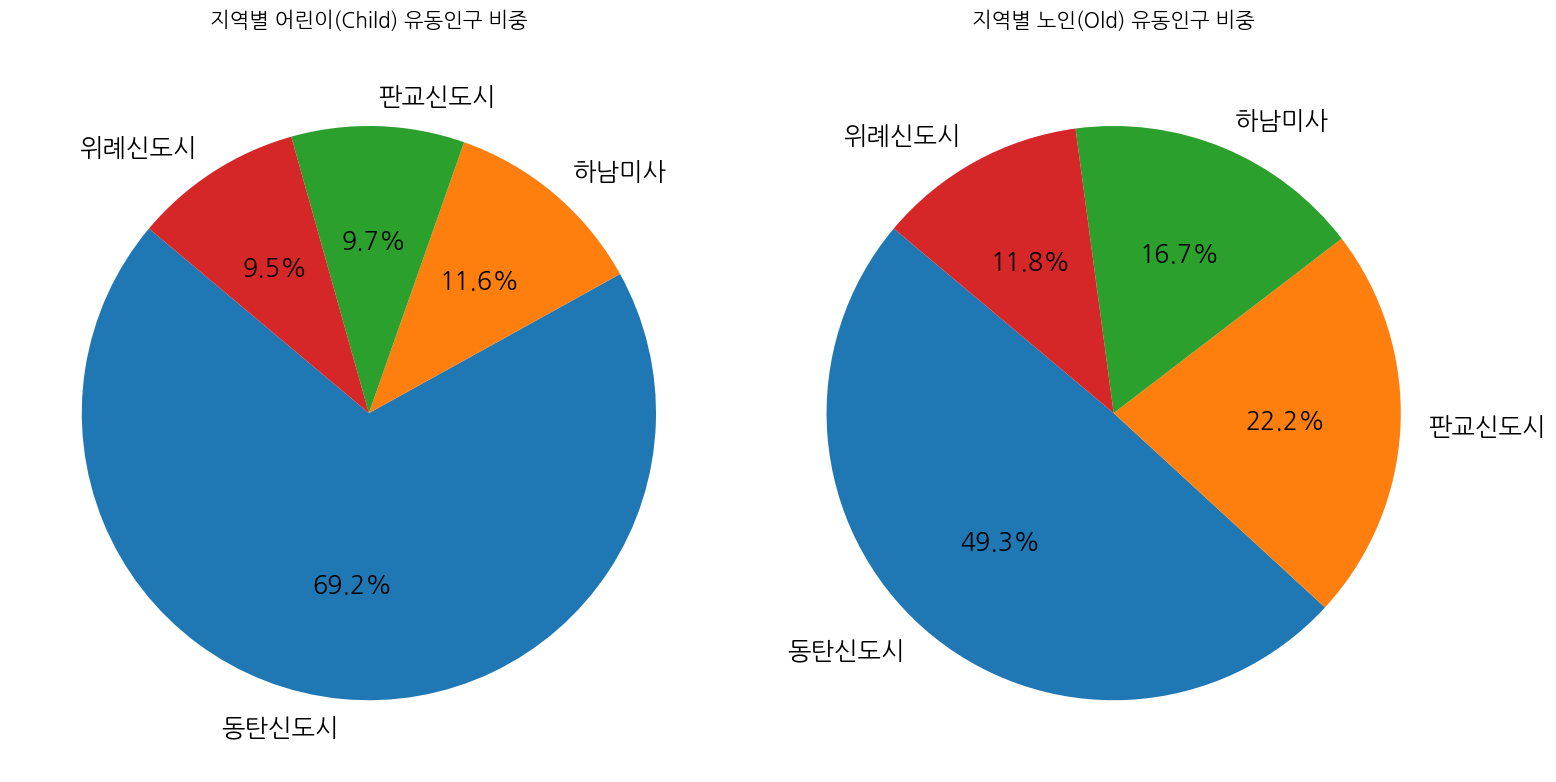

In [ ]:
# 1. 데이터 준비 (어린이/노인 각각 집계 및 정렬)
child_df = iv_peo2.groupby('zoneName')['child_pop'].sum().sort_values(ascending=False)
old_df = iv_peo2.groupby('zoneName')['old_pop'].sum().sort_values(ascending=False)

# 2. 그래프 설정 (1행 2열 구성)
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# 3. 어린이 유동인구 파이 차트 (왼쪽)
ax[0].pie(child_df, 
          labels=child_df.index, 
          autopct='%1.1f%%', 
          startangle=140, 
         ) 
ax[0].set_title('지역별 어린이(Child) 유동인구 비중', fontsize=15, pad=20)

# 4. 노인 유동인구 파이 차트 (오른쪽)
ax[1].pie(old_df, 
          labels=old_df.index, 
          autopct='%1.1f%%', 
          startangle=140, 
         )
ax[1].set_title('지역별 노인(Old) 유동인구 비중', fontsize=15, pad=20)

plt.tight_layout()
plt.show()

## 5) 격자 단위 유동인구 재집계

In [ ]:
# 위경도별 월평균 인구로 대치
iv_peo2_mean = iv_peo2.groupby(["lon","lat"]).agg({
    "zoneName":"first",
    "child_pop":"mean",
    "old_pop":"mean"
}).reset_index()

,lon,lat,zoneName,child_pop,old_pop
0,127.049023,37.209370,동탄신도시,4.866667,7.888333
1,127.049025,37.208920,동탄신도시,4.940000,9.706667
2,127.049028,37.208469,동탄신도시,3.371667,5.798333
3,127.049031,37.208018,동탄신도시,1.276667,2.070000
4,127.049033,37.207568,동탄신도시,0.407500,0.632500


In [ ]:
iv_peo2_grid = gpd.GeoDataFrame(
    iv_peo2_mean,
    geometry=gpd.points_from_xy(iv_peo2_mean.lon, iv_peo2_mean.lat),
    crs="EPSG:4326"
)
grid = gpd.read_file("01._격자_(4개_시·구).geojson")

grid = grid.to_crs("EPSG:4326")
iv_peo2_grid = gpd.sjoin(iv_peo2_grid, grid, how="left", predicate="within")
iv_peo2_grid = iv_peo2_grid.groupby(["zoneName","gid"])[["child_pop","old_pop"]].sum().reset_index()

## 6) 어린이·노인 유동인구 히트맵

In [ ]:
# 유동인구 히트맵: 어린이
# grid에서 centroid 생성
grid['lat'] = grid.geometry.centroid.y
grid['lng'] = grid.geometry.centroid.x

# gid 기준으로 병합
iv_peo2_grid = iv_peo2_grid.merge(
    grid[['gid','lat','lng']],
    on='gid',
    how='left'
)

m_child = folium.Map(
    location=[iv_peo2_grid['lat'].mean(), iv_peo2_grid['lng'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

heat_child = iv_peo2_grid[['lat','lng','child_pop']].values.tolist()

HeatMap(heat_child, radius=10, blur=14).add_to(m_child)
m_child

/tmp/ipykernel_535/2125152441.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['lat'] = grid.geometry.centroid.y
/tmp/ipykernel_535/2125152441.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['lng'] = grid.geometry.centroid.x


In [ ]:
# 유동인구 히트맵: 노인 (배경 지도 변경 버전)

# 1. tiles 옵션 추가
m_old = folium.Map(
    location=[iv_peo2_grid['lat'].mean(), iv_peo2_grid['lng'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"  # 여기에 추가!
)

heat_old = iv_peo2_grid[['lat','lng','old_pop']].values.tolist()

# 2. 히트맵 
HeatMap(heat_old, radius=10, blur=14, min_opacity=0.3).add_to(m_old)

m_old

## 7) 거주인구 기반 노인 인구 산출

In [ ]:
iv_peo1=iv_peo1.fillna(0)

,gbn,gid,year,m_20g_pop,w_20g_pop,m_30g_pop,w_30g_pop,m_40g_pop,w_40g_pop,m_50g_pop,...,m_60g_pop,w_60g_pop,m_70g_pop,w_70g_pop,m_80g_pop,w_80g_pop,m_90g_pop,w_90g_pop,m_100g_pop,w_100g_pop
0,경기도 성남시,다사581304,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,경기도 성남시,다사581305,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,경기도 성남시,다사581306,2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
iv_peo1['old_pop'] = iv_peo1['m_60g_pop'] + iv_peo1['w_60g_pop']+ iv_peo1['m_70g_pop'] + iv_peo1['w_70g_pop'] \
                   + iv_peo1['m_80g_pop'] + iv_peo1['w_80g_pop'] + iv_peo1['m_90g_pop'] + iv_peo1['w_90g_pop'] \
                   + iv_peo1['m_100g_pop'] + iv_peo1['w_100g_pop']
iv_peo1=iv_peo1[['gbn', 'gid', 'year', 'old_pop']]

,gbn,gid,year,old_pop
99293,서울특별시 송파구,다사697448,2024,0.0
99294,서울특별시 송파구,다사697449,2024,0.0
99295,서울특별시 송파구,다사698434,2024,0.0
99296,서울특별시 송파구,다사698436,2024,0.0
99297,서울특별시 송파구,다사698437,2024,54.0
99298,서울특별시 송파구,다사698438,2024,0.0
99299,서울특별시 송파구,다사698439,2024,62.0
99300,서울특별시 송파구,다사698440,2024,176.0
99301,서울특별시 송파구,다사698441,2024,113.0
99302,서울특별시 송파구,다사698442,2024,174.0


In [ ]:
iv_peo1_merged = pd.merge(iv_peo1, geo1[['gid', 'geometry']], on='gid', how='inner')

print(f"합치기 전 행 수: {len(iv_peo1)}")
print(f"합친 후 행 수: {len(iv_peo1_merged)}")
print(iv_peo1_merged.head(3))


합치기 전 행 수: 99323
합친 후 행 수: 99679
       gbn       gid  year  old_pop  \
0  경기도 성남시  다사581304  2024      0.0   
1  경기도 성남시  다사581305  2024      0.0   
2  경기도 성남시  다사581306  2024      0.0   

                                            geometry  
0  POLYGON ((127.02677 37.37172, 127.02677 37.372...  
1  POLYGON ((127.02677 37.37262, 127.02676 37.373...  
2  POLYGON ((127.02676 37.37352, 127.02676 37.374...  


## 8) 4개 신도시 기준 재분류

In [ ]:
# 1. geo1에서 중복된 gid 리스트 추출 (위례신도시 혼재 구역)
wirae_mixed_gids = geo1[geo1['gid'].duplicated(keep=False)]['gid'].unique()

# 2. 신도시 분류 로직 적용 (iv_peo1_merged 기준)
# 조건 A: 위례신도시 (중복된 gid이거나, 지자체가 서울특별시 송파구인 경우)
cond_wirae = (iv_peo1_merged['gid'].isin(wirae_mixed_gids)) | \
             (iv_peo1_merged['gbn'] == '서울특별시 송파구')

# 조건 B: 판교신도시 (성남시이면서 위례가 아닌 경우)
cond_pangyo = (iv_peo1_merged['gbn'] == '경기도 성남시') & (~iv_peo1_merged['gid'].isin(wirae_mixed_gids))

# 조건 C: 하남미사 (하남시이면서 위례가 아닌 경우)
cond_hanam = (iv_peo1_merged['gbn'] == '경기도 하남시') & (~iv_peo1_merged['gid'].isin(wirae_mixed_gids))

# 조건 D: 동탄신도시 (화성시 전체)
cond_dongtan = (iv_peo1_merged['gbn'] == '경기도 화성시')

# 3. 새로운 gbn_final 컬럼 생성
conditions = [cond_wirae, cond_pangyo, cond_hanam, cond_dongtan]
choices = ['위례신도시', '판교신도시', '하남미사', '동탄신도시']

iv_peo1_merged['gbn_final'] = np.select(conditions, choices, default='기타')

# 4. 중복된 행 제거 (이제 지역 분류가 끝났으므로 하나만 남김)
iv_peo1_final = iv_peo1_merged.drop_duplicates(subset=['gid']).copy()

# 5. gbn 컬럼을 최종 분류명으로 교체
iv_peo1_final['gbn'] = iv_peo1_final['gbn_final']
iv_peo1_final = iv_peo1_final.drop(columns=['gbn_final'])

print(iv_peo1_final['gbn'].value_counts())


gbn
동탄신도시    71599
판교신도시    14436
하남미사      9490
위례신도시     3621
Name: count, dtype: int64


/tmp/ipykernel_535/160636150.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df_bar, x='gbn', y='old_pop', palette='muted')


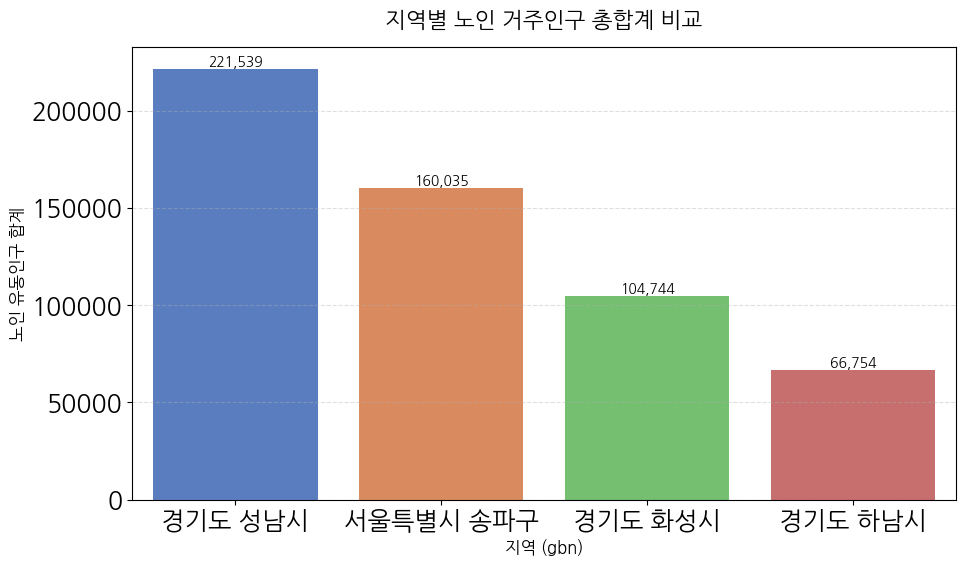

In [ ]:
plot_df_bar = iv_peo1.groupby('gbn')['old_pop'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df_bar, x='gbn', y='old_pop', palette='muted')

plt.title('지역별 노인 거주인구 총합계 비교', fontsize=16, pad=15)
plt.xlabel('지역 (gbn)', fontsize=12)
plt.ylabel('노인 유동인구 합계', fontsize=12)

for i, val in enumerate(plot_df_bar['old_pop']):
    plt.text(i, val, f'{int(val):,}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [41]:
iv_peo3 = iv_peo3.fillna(0)

## 9) 시간대별 직장인구 분포 분석

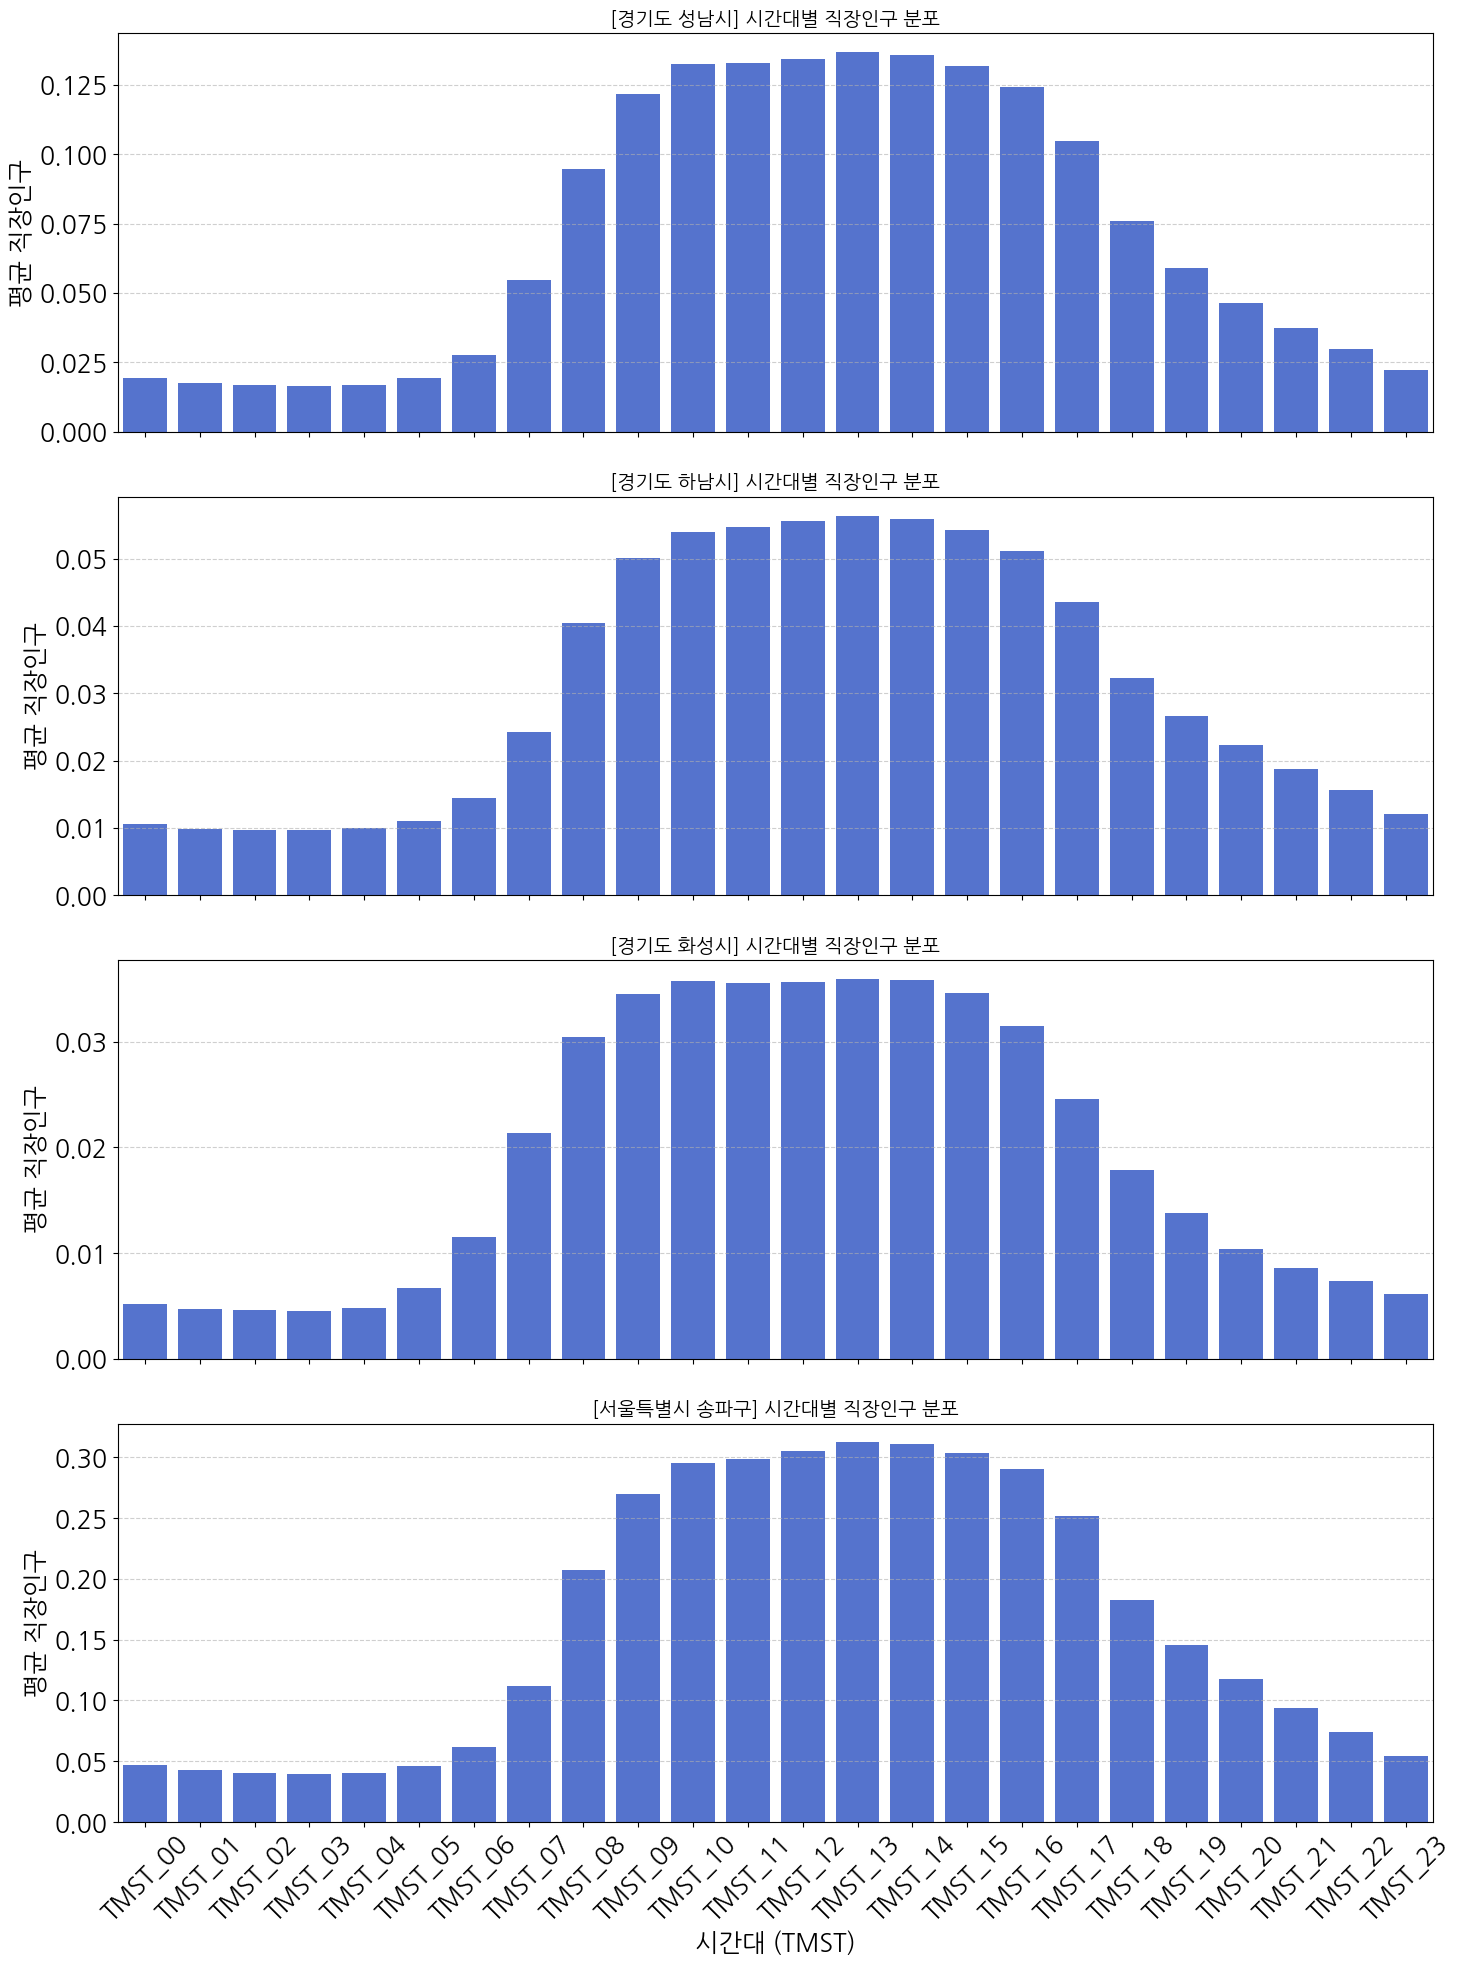

In [ ]:
# 1. 시각화용 데이터 정리 (지역별/시간대별 평균 계산)
# TMST_로 시작하는 시간대 컬럼들만 추출
tmst_cols = [f'TMST_{i:02d}' for i in range(24)]
plot_df = iv_peo3.groupby('gbn')[tmst_cols].mean().reset_index()

plot_df_melted = plot_df.melt(id_vars='gbn', var_name='Hour', value_name='Work_Pop')

regions = plot_df_melted['gbn'].unique()
fig, axes = plt.subplots(len(regions), 1, figsize=(15, 5 * len(regions)), sharex=True)

for i, region in enumerate(regions):
    data = plot_df_melted[plot_df_melted['gbn'] == region]
    sns.barplot(data=data, x='Hour', y='Work_Pop', ax=axes[i], color='royalblue')
    
    axes[i].set_title(f'[{region}] 시간대별 직장인구 분포', fontsize=14)
    axes[i].set_ylabel('평균 직장인구')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.xlabel('시간대 (TMST)')
plt.tight_layout()
plt.show()

## 10) 시간대 구간별 직장인구 재구성

In [ ]:
iv_peo3['AM_Peak'] = iv_peo3['TMST_06'] + iv_peo3['TMST_07']+ iv_peo3['TMST_08'] + iv_peo3['TMST_09'] #6~9
iv_peo3['Midday'] = iv_peo3['TMST_10'] + iv_peo3['TMST_11']+ iv_peo3['TMST_12'] + iv_peo3['TMST_13']+ iv_peo3['TMST_14'] + iv_peo3['TMST_15'] #10~15
iv_peo3['PM_Peak'] = iv_peo3['TMST_16'] + iv_peo3['TMST_17']+ iv_peo3['TMST_18'] + iv_peo3['TMST_19']  #16~19
iv_peo3['eve_dawn'] = iv_peo3['TMST_20'] + iv_peo3['TMST_21']+ iv_peo3['TMST_22'] + iv_peo3['TMST_23']+ iv_peo3['TMST_00'] + iv_peo3['TMST_01']\
                    + iv_peo3['TMST_02'] + iv_peo3['TMST_03']+ iv_peo3['TMST_04'] + iv_peo3['TMST_05'] #20~5
iv_peo3_slot=iv_peo3[['gbn','STD_YM', 'AM_Peak', 'Midday', 'PM_Peak', 'eve_dawn', 'lon', 'lat']]

,gbn,STD_YM,AM_Peak,Midday,PM_Peak,eve_dawn,lon,lat
0,경기도 성남시,202401,0.012667,0.029167,0.007,0.0,127.027716,37.372890
1,경기도 성남시,202401,0.000000,0.000000,0.000,0.0,127.028272,37.374244
2,경기도 성남시,202401,0.003333,0.015000,0.010,0.0,127.028275,37.373793
3,경기도 성남시,202401,0.012667,0.029167,0.007,0.0,127.028278,37.373343
4,경기도 성남시,202401,0.003333,0.015000,0.010,0.0,127.028281,37.372892


In [ ]:
# 직장인구는 월별 차이가 의미없을것 같음
iv_peo3_slot=iv_peo3_slot.groupby(['gbn', 'STD_YM'])[['AM_Peak', 'Midday', 'PM_Peak', 'eve_dawn']].mean().reset_index()

,AM_Peak,Midday,PM_Peak,eve_dawn
gbn,,,,
경기도 성남시,0.299037,0.803954,0.364213,0.242652
경기도 하남시,0.129107,0.330743,0.153465,0.129789
경기도 화성시,0.097768,0.213453,0.087662,0.062987
서울특별시 송파구,0.650891,1.827039,0.870994,0.595736


## 11) 시간대 구간별 직장인구 비교

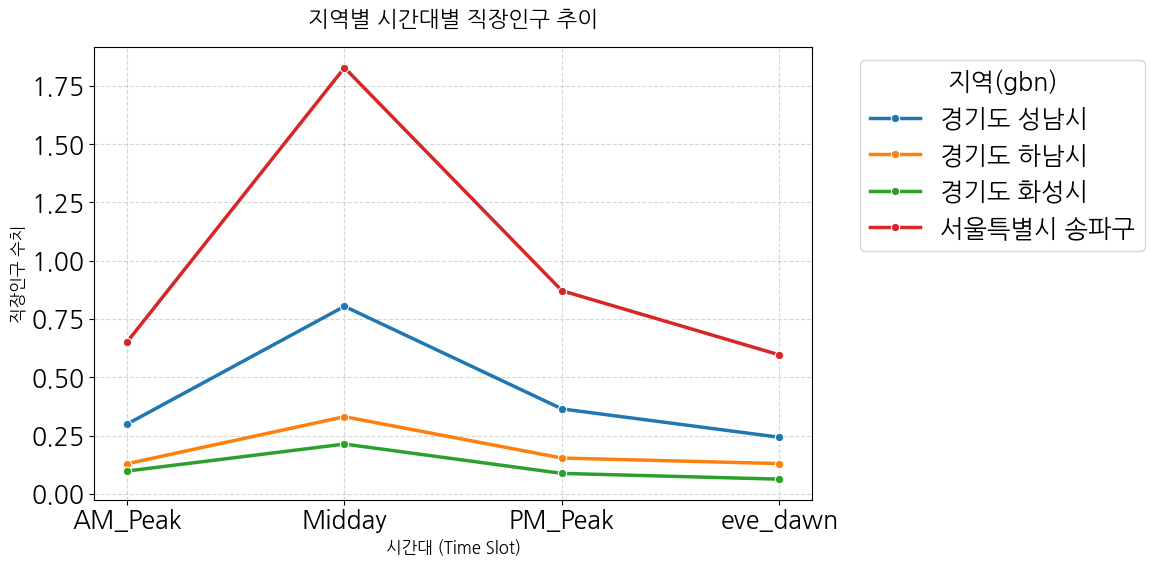

In [ ]:
df=iv_peo3_slot.groupby(['gbn'])[['AM_Peak', 'Midday', 'PM_Peak', 'eve_dawn']].mean()
plot_df = df.T 

plt.figure(figsize=(12, 6))

sns.lineplot(data=plot_df, dashes=False, marker='o', linewidth=2.5)

plt.title('지역별 시간대별 직장인구 추이', fontsize=16, pad=15)
plt.xlabel('시간대 (Time Slot)', fontsize=12)
plt.ylabel('직장인구 수치', fontsize=12)
plt.legend(title='지역(gbn)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()